In [ ]:
pip install yfinance

In [ ]:
import yfinance as yf

# Define the ticker symbols
ticker_symbols = ["GC=F", "BTC-USD"]

# Dictionary to store historical data for each ticker
historical_data = {}

for symbol in ticker_symbols:
    print(f"Fetching data for {symbol}...")
    ticker = yf.Ticker(symbol)
    # Get historical market data for the last 5 years
    df_historical = ticker.history(period="5y")
    historical_data[symbol] = df_historical
    print(f"\nFirst 5 rows for {symbol}:")
    display(df_historical.head())


Fetching data for GC=F...

First 5 rows for GC=F:


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-06-03 00:00:00-04:00,1908.800049,1908.800049,1865.000000,1871.199951,1021,0.0,0.0
2021-06-04 00:00:00-04:00,1869.300049,1895.500000,1854.000000,1889.800049,367,0.0,0.0
2021-06-07 00:00:00-04:00,1890.500000,1899.699951,1883.199951,1896.800049,87,0.0,0.0
2021-06-08 00:00:00-04:00,1896.500000,1902.900024,1890.000000,1892.199951,930,0.0,0.0
2021-06-09 00:00:00-04:00,1894.900024,1897.699951,1889.199951,1893.199951,148,0.0,0.0


Fetching data for BTC-USD...

First 5 rows for BTC-USD:


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-06-03 00:00:00+00:00,37599.410156,39478.953125,37243.972656,39208.765625,35460750427,0.0,0.0
2021-06-04 00:00:00+00:00,39242.484375,39242.484375,35717.722656,36894.406250,41831090187,0.0,0.0
2021-06-05 00:00:00+00:00,36880.156250,37917.714844,34900.414062,35551.957031,35959473399,0.0,0.0
2021-06-06 00:00:00+00:00,35538.609375,36436.421875,35304.578125,35862.378906,28913440585,0.0,0.0
2021-06-07 00:00:00+00:00,35835.265625,36790.570312,33480.640625,33560.707031,33683936663,0.0,0.0


### Daily Returns Analysis

First, let's calculate the daily returns for both 'GC=F' (Gold) and 'BTC-USD' (Bitcoin) using their 'Close' prices. Daily returns are calculated as the percentage change in the closing price from one day to the next.

In [ ]:
# Calculate daily returns for each ticker
daily_returns = {}
for symbol, df in historical_data.items():
    daily_returns[symbol] = df['Close'].pct_change().dropna()

# Display the first few daily returns for each
print("Daily Returns for GC=F:")
display(daily_returns['GC=F'].head())

print("\nDaily Returns for BTC-USD:")
display(daily_returns['BTC-USD'].head())

Daily Returns for GC=F:


,Close
Date,
2021-06-04 00:00:00-04:00,0.009940
2021-06-07 00:00:00-04:00,0.003704
2021-06-08 00:00:00-04:00,-0.002425
2021-06-09 00:00:00-04:00,0.000528
2021-06-10 00:00:00-04:00,0.000528



Daily Returns for BTC-USD:


,Close
Date,
2021-06-04 00:00:00+00:00,-0.059027
2021-06-05 00:00:00+00:00,-0.036386
2021-06-06 00:00:00+00:00,0.008731
2021-06-07 00:00:00+00:00,-0.064181
2021-06-08 00:00:00+00:00,-0.002624


Now, let's visualize the distribution of these daily returns using histograms. This will give us an idea of the frequency of different return values and highlight any extreme movements.

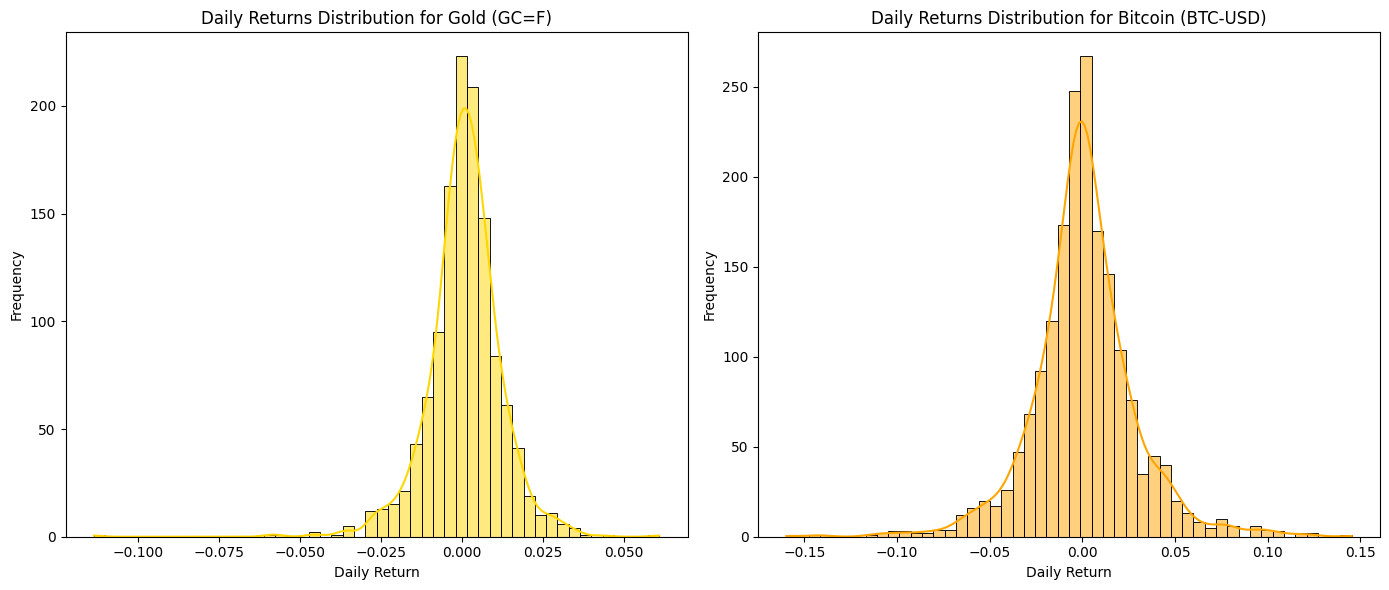

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Plot daily returns for Gold (GC=F)
plt.subplot(1, 2, 1)
sns.histplot(daily_returns['GC=F'], bins=50, kde=True, color='gold')
plt.title('Daily Returns Distribution for Gold (GC=F)')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

# Plot daily returns for Bitcoin (BTC-USD)
plt.subplot(1, 2, 2)
sns.histplot(daily_returns['BTC-USD'], bins=50, kde=True, color='orange')
plt.title('Daily Returns Distribution for Bitcoin (BTC-USD)')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Cumulative Returns Analysis

Next, let's look at the cumulative returns over the 5-year period for both assets. Cumulative returns show the total growth of an investment over time.

In [ ]:
# Calculate cumulative returns for each ticker
cumulative_returns = {}
for symbol in daily_returns:
    # Add 1 to daily returns and then compute the cumulative product
    # Subtract 1 at the end to get the actual cumulative return percentage
    cum_ret = (1 + daily_returns[symbol]).cumprod() - 1
    cumulative_returns[symbol] = cum_ret

# Display the last few cumulative returns for each
print("Cumulative Returns for GC=F (last 5 rows):")
display(cumulative_returns['GC=F'].tail())

print("\nCumulative Returns for BTC-USD (last 5 rows):")
display(cumulative_returns['BTC-USD'].tail())

Cumulative Returns for GC=F (last 5 rows):


,Close
Date,
2026-05-28 00:00:00-04:00,1.404500
2026-05-29 00:00:00-04:00,1.437206
2026-06-01 00:00:00-04:00,1.391621
2026-06-02 00:00:00-04:00,1.399049
2026-06-03 00:00:00-04:00,1.398995



Cumulative Returns for BTC-USD (last 5 rows):


,Close
Date,
2026-05-30 00:00:00+00:00,0.881080
2026-05-31 00:00:00+00:00,0.876613
2026-06-01 00:00:00+00:00,0.818975
2026-06-02 00:00:00+00:00,0.701243
2026-06-03 00:00:00+00:00,0.708645


Finally, let's visualize the cumulative returns over time. This plot will show the performance of both Gold and Bitcoin over the 5-year period.

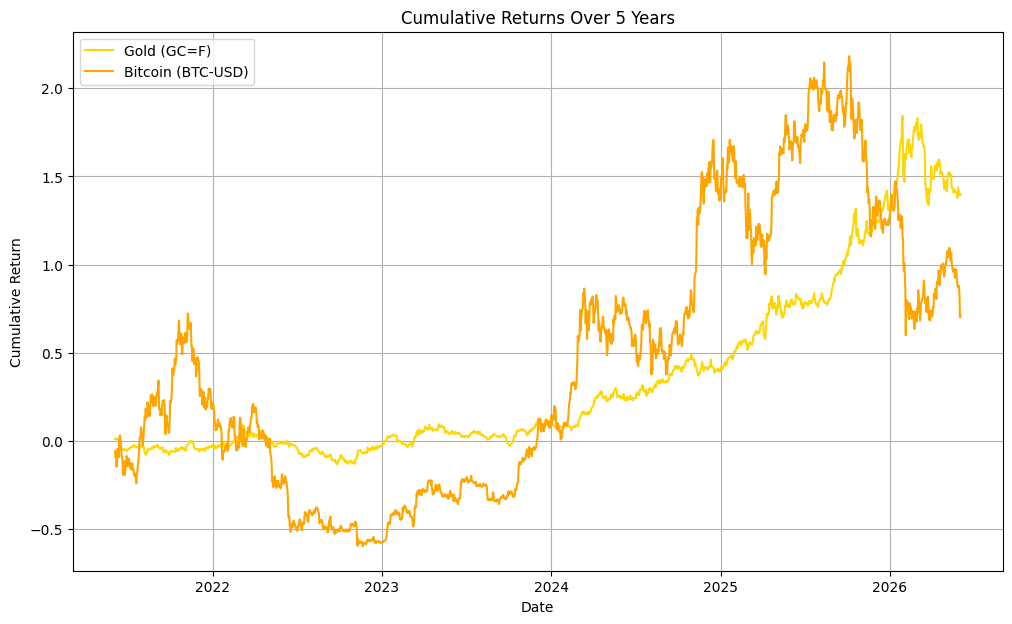

In [ ]:
plt.figure(figsize=(12, 7))

plt.plot(cumulative_returns['GC=F'].index, cumulative_returns['GC=F'], label='Gold (GC=F)', color='gold')
plt.plot(cumulative_returns['BTC-USD'].index, cumulative_returns['BTC-USD'], label='Bitcoin (BTC-USD)', color='orange')

plt.title('Cumulative Returns Over 5 Years')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

### Compound Annual Growth Rate (CAGR) Analysis

CAGR represents the average annual growth rate of an investment over a specified period longer than one year. It smooths out volatile returns and provides a clearer picture of an investment's performance.

In [ ]:
import pandas as pd

def calculate_cagr(df):
    # Ensure the DataFrame has a 'Close' column and is indexed by Date
    if 'Close' not in df.columns or not isinstance(df.index, pd.DatetimeIndex):
        return None

    # Get the start and end prices
    start_price = df['Close'].iloc[0]
    end_price = df['Close'].iloc[-1]

    # Calculate the number of years (period length)
    # We subtract 1 from the length of the DataFrame to get the number of periods, then divide by the approximate number of trading days in a year
    # Alternatively, use date difference directly for more accuracy in years
    first_date = df.index.min()
    last_date = df.index.max()
    num_years = (last_date - first_date).days / 365.25 # Account for leap years

    if num_years <= 0:
        return 0.0 # Return 0 if the period is not long enough for CAGR

    # Calculate CAGR
    cagr = ((end_price / start_price)**(1 / num_years)) - 1
    return cagr

# Calculate CAGR for each ticker
cagr_results = {}
for symbol, df in historical_data.items():
    cagr = calculate_cagr(df)
    if cagr is not None:
        cagr_results[symbol] = cagr

# Display the CAGR results
print("Compound Annual Growth Rate (CAGR) for each ticker:")
for symbol, cagr_value in cagr_results.items():
    print(f"{symbol}: {cagr_value:.2%}")

Compound Annual Growth Rate (CAGR) for each ticker:
GC=F: 19.13%
BTC-USD: 11.31%


### Descriptive Analytics: Price Statistics

Let's calculate and display basic descriptive statistics for the 'Close' prices of both Gold (GC=F) and Bitcoin (BTC-USD). This will provide insights into their central tendency, dispersion, and shape of distribution.

In [ ]:
import pandas as pd

# Prepare a DataFrame to hold the 'Close' prices for comparison
close_prices = pd.DataFrame({
    'GC=F': historical_data['GC=F']['Close'],
    'BTC-USD': historical_data['BTC-USD']['Close']
})

# Display descriptive statistics for 'Close' prices
print("Descriptive Statistics for Close Prices:")
display(close_prices.describe())

Descriptive Statistics for Close Prices:


,GC=F,BTC-USD
count,1258.000000,1827.000000
mean,2524.271537,56810.568789
std,946.128615,29935.172968
min,1623.300049,15787.284180
25%,1836.574951,29412.204102
50%,2017.700012,49958.222656
75%,2924.274902,78673.152344
max,5318.399902,124752.531250


### Descriptive Analytics: Price Trends

Next, let's visualize the 'Close' price trends of both assets over the 5-year period. This will help us observe overall patterns, volatility, and major price movements.

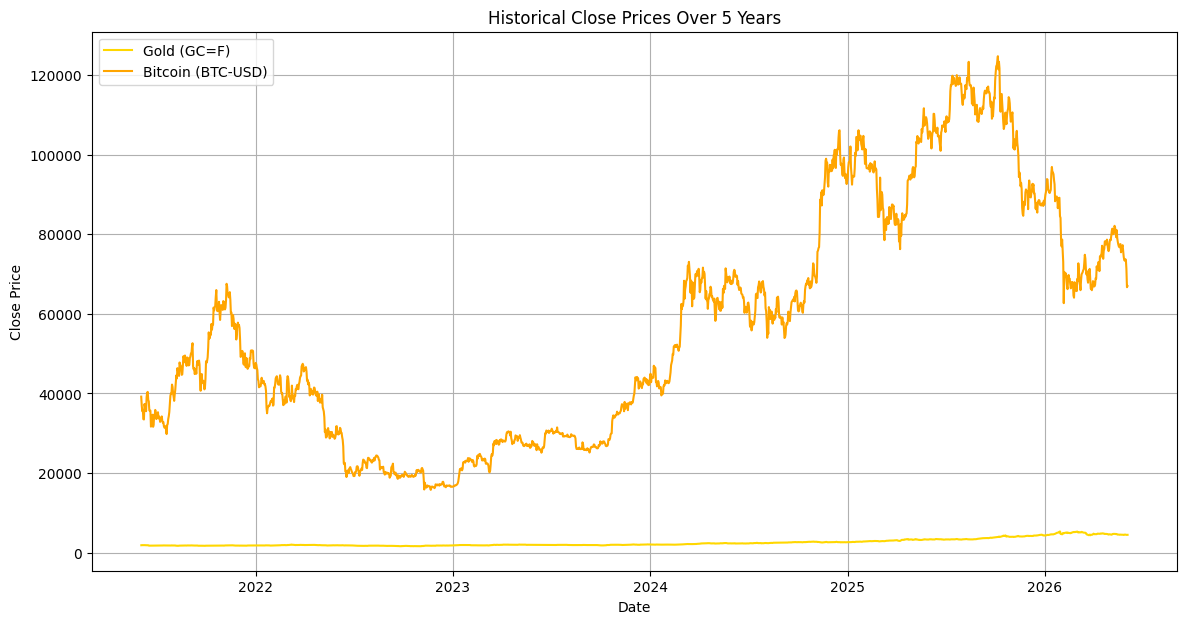

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

# Plot Gold (GC=F) Close prices
plt.plot(historical_data['GC=F'].index, historical_data['GC=F']['Close'], label='Gold (GC=F)', color='gold')

# Plot Bitcoin (BTC-USD) Close prices
plt.plot(historical_data['BTC-USD'].index, historical_data['BTC-USD']['Close'], label='Bitcoin (BTC-USD)', color='orange')

plt.title('Historical Close Prices Over 5 Years')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

### Descriptive Statistics Table

In [ ]:
display(close_prices.describe())

,GC=F,BTC-USD
count,1258.000000,1827.000000
mean,2524.271537,56810.568789
std,946.128615,29935.172968
min,1623.300049,15787.284180
25%,1836.574951,29412.204102
50%,2017.700012,49958.222656
75%,2924.274902,78673.152344
max,5318.399902,124752.531250


### Research Question 1: Which asset offers higher investment returns?

Based on the Compound Annual Growth Rate (CAGR) analysis over the 5-year period:

*   **Gold (GC=F)** had a CAGR of approximately **19.13%**.
*   **Bitcoin (BTC-USD)** had a CAGR of approximately **11.31%**.

Therefore, **Gold (GC=F) offered higher investment returns** compared to Bitcoin (BTC-USD) during this specific 5-year period.

### Volatility Analysis: Standard Deviation of Daily Returns

Volatility is a measure of the dispersion of returns for a given asset. A higher standard deviation indicates higher volatility, meaning the asset's price can fluctuate more dramatically. Let's calculate the standard deviation of the daily returns for both Gold and Bitcoin.

In [ ]:
import numpy as np

# Calculate the standard deviation of daily returns for each asset
volatility = {symbol: daily_returns[symbol].std() for symbol in daily_returns}

print("Standard Deviation of Daily Returns (Volatility):")
for symbol, std_dev in volatility.items():
    print(f"{symbol}: {std_dev:.4f}")

Standard Deviation of Daily Returns (Volatility):
GC=F: 0.0115
BTC-USD: 0.0282


### Volatility Analysis: Visualizing Daily Return Distributions

To further visualize the volatility, we can use violin plots, which show the distribution of daily returns, including density and quartiles. A wider and taller violin indicates higher volatility.

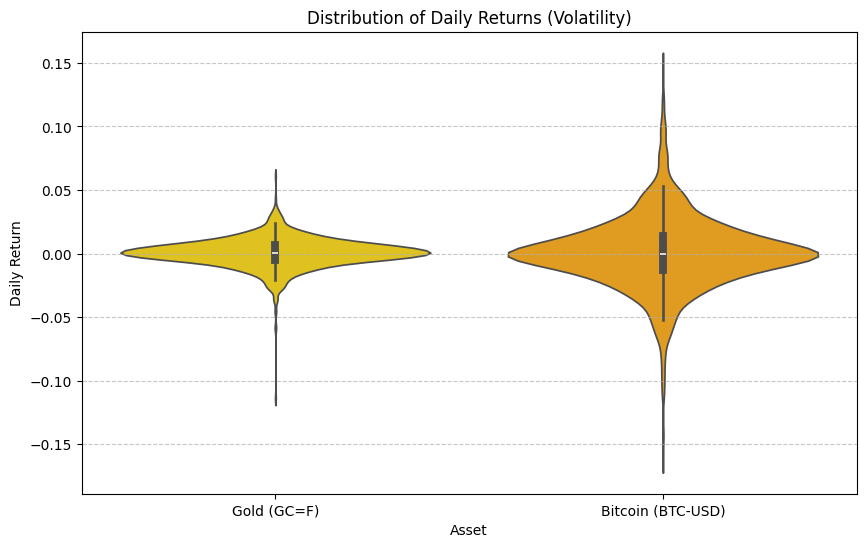

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine daily returns into a single DataFrame for easier plotting
combined_daily_returns = pd.DataFrame({
    'Gold (GC=F)': daily_returns['GC=F'],
    'Bitcoin (BTC-USD)': daily_returns['BTC-USD']
})

plt.figure(figsize=(10, 6))
sns.violinplot(data=combined_daily_returns, palette=['gold', 'orange'])
plt.title('Distribution of Daily Returns (Volatility)')
plt.ylabel('Daily Return')
plt.xlabel('Asset')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Volatility Summary

Based on the volatility analysis:

*   **Gold (GC=F)** had a standard deviation of daily returns of approximately **0.0115**.
*   **Bitcoin (BTC-USD)** had a standard deviation of daily returns of approximately **0.0282**.

This indicates that **Bitcoin (BTC-USD) exhibits significantly higher volatility** compared to Gold (GC=F) over the analyzed 5-year period. The violin plot visually confirms this, showing a broader distribution for Bitcoin's daily returns, signifying more frequent and larger price fluctuations.

### Sharpe Ratio Analysis: Risk-Adjusted Returns

The Sharpe Ratio measures the performance of an investment compared to a risk-free asset, after adjusting for its risk. It is defined as the excess return per unit of standard deviation of return. A higher Sharpe Ratio indicates a better risk-adjusted return.

$Sharpe Ratio = \frac{R_p - R_f}{\sigma_p}$

Where:
*   $R_p$ is the expected portfolio return
*   $R_f$ is the risk-free rate
*   $\sigma_p$ is the standard deviation of the portfolio's excess return (volatility)

In [ ]:
import numpy as np

# Assuming a risk-free rate for simplicity (e.g., 0 or a typical bond yield)
# For a more precise analysis, an appropriate risk-free rate (e.g., US Treasury bill rate) for the period should be used.
risk_free_rate_annual = 0.01 # 1% annual risk-free rate
risk_free_rate_daily = (1 + risk_free_rate_annual)**(1/252) - 1 # Convert to daily rate (252 trading days)

sharpe_ratios = {}
for symbol in daily_returns:
    avg_daily_return = daily_returns[symbol].mean()
    std_dev_daily_return = daily_returns[symbol].std()

    # Calculate daily Sharpe Ratio
    if std_dev_daily_return == 0:
        sharpe_daily = np.nan # Avoid division by zero
    else:
        sharpe_daily = (avg_daily_return - risk_free_rate_daily) / std_dev_daily_return

    # Annualize the Sharpe Ratio (multiply by square root of trading days in a year)
    sharpe_ratios[symbol] = sharpe_daily * np.sqrt(252)

print("Annualized Sharpe Ratios:")
for symbol, sharpe_value in sharpe_ratios.items():
    print(f"{symbol}: {sharpe_value:.2f}")

Annualized Sharpe Ratios:
GC=F: 1.00
BTC-USD: 0.37


### Maximum Drawdown Analysis

Maximum Drawdown (MDD) is the maximum observed loss from a peak to a trough of a portfolio, before a new peak is attained. It is an indicator of the downside risk over a specified time period. A high MDD means that an investment has experienced a significant drop at some point.

In [ ]:
def calculate_max_drawdown(prices):
    # Calculate the cumulative maximum price (peak)
    cumulative_max = prices.cummax()

    # Calculate the drawdown from the peak
    drawdown = (prices / cumulative_max) - 1

    # The maximum drawdown is the minimum (most negative) value of the drawdown
    max_drawdown = drawdown.min()
    return max_drawdown

# Calculate Maximum Drawdown for each ticker
max_drawdowns = {}
for symbol, df in historical_data.items():
    # We use the 'Close' prices for this analysis
    max_drawdowns[symbol] = calculate_max_drawdown(df['Close'])

print("Maximum Drawdown for each ticker:")
for symbol, mdd_value in max_drawdowns.items():
    print(f"{symbol}: {mdd_value:.2%}")

Maximum Drawdown for each ticker:
GC=F: -20.43%
BTC-USD: -76.63%


### Maximum Drawdown Summary

Based on the Maximum Drawdown analysis:

*   **Gold (GC=F)** experienced a maximum drawdown of approximately **-20.43%**.
*   **Bitcoin (BTC-USD)** experienced a maximum drawdown of approximately **-76.63%**.

This indicates that Bitcoin had a much more significant and deeper decline from its peak compared to Gold during the analyzed 5-year period, further highlighting its higher risk profile.

### Research Question 2: Which asset offers lower investment risk?

Based on the comprehensive risk analysis encompassing volatility, Sharpe Ratio, and Maximum Drawdown:

*   **Volatility (Standard Deviation of Daily Returns):**
    *   Gold (GC=F): ~0.0115
    *   Bitcoin (BTC-USD): ~0.0282
    *   **Conclusion:** Bitcoin exhibits significantly higher volatility, indicating greater price fluctuations.

*   **Sharpe Ratio (Risk-Adjusted Returns):**
    *   Gold (GC=F): 1.00
    *   Bitcoin (BTC-USD): 0.37
    *   **Conclusion:** Gold offers a substantially better risk-adjusted return, meaning it generates more return per unit of risk taken.

*   **Maximum Drawdown (Largest Peak-to-Trough Decline):**
    *   Gold (GC=F): -20.43%
    *   Bitcoin (BTC-USD): -76.63%
    *   **Conclusion:** Bitcoin experienced a much deeper and more severe drawdown from its peak, indicating higher downside risk.

Considering these metrics, **Gold (GC=F) consistently demonstrates a lower investment risk** profile compared to Bitcoin (BTC-USD) over the analyzed 5-year period. Gold has lower volatility, better risk-adjusted returns (higher Sharpe Ratio), and significantly less severe maximum drawdowns.

### Overall Summary of Gold vs. Bitcoin (5-Year Analysis)

We have analyzed the performance of Gold (GC=F) and Bitcoin (BTC-USD) over a 5-year period, focusing on investment returns and investment risk.

**Key Findings:**

*   **Investment Returns (CAGR):**
    *   **Gold (GC=F):** ~19.13%
    *   **Bitcoin (BTC-USD):** ~11.31%
    *   **Conclusion:** Gold offered higher investment returns during this specific 5-year period.

*   **Investment Risk:**
    *   **Volatility (Standard Deviation of Daily Returns):** Gold (~0.0115) was significantly less volatile than Bitcoin (~0.0282).
    *   **Sharpe Ratio (Risk-Adjusted Returns):** Gold (1.00) showed a much better risk-adjusted return than Bitcoin (0.37).
    *   **Maximum Drawdown (Largest Peak-to-Trough Decline):** Gold (-20.43%) experienced a far less severe drawdown compared to Bitcoin (-76.63%).
    *   **Conclusion:** **Gold (GC=F) consistently demonstrates a lower investment risk** profile compared to Bitcoin (BTC-USD) over the analyzed 5-year period.

In summary, while Gold showed better returns and significantly lower risk in this particular 5-year window, Bitcoin presented a much riskier profile with higher price swings and potential for larger losses. An investor's choice between these two assets would heavily depend on their risk tolerance and investment goals, with Gold being suitable for more risk-averse investors seeking stability and Bitcoin for those willing to accept higher risk for potentially higher, though more volatile, returns.

### Final Conclusion: Gold vs. Bitcoin Investment Performance

Our 5-year comparative analysis of Gold (GC=F) and Bitcoin (BTC-USD) has provided a comprehensive overview of their investment performance and risk profiles.

**Key Takeaways:**

*   **Investment Returns:** Gold outperformed Bitcoin in terms of raw returns, with a CAGR of approximately 19.13% for Gold versus 11.31% for Bitcoin.

*   **Investment Risk:** Gold consistently demonstrated a significantly lower investment risk profile across all metrics:
    *   **Volatility:** Gold exhibited much lower daily return volatility (0.0115) compared to Bitcoin (0.0282).
    *   **Sharpe Ratio:** Gold yielded a substantially better risk-adjusted return (1.00) than Bitcoin (0.37).
    *   **Maximum Drawdown:** Gold experienced a considerably shallower maximum drawdown (-20.43%) compared to Bitcoin (-76.63%), indicating greater resilience to significant price declines.

**In summary, over the past five years, Gold presented itself as a more stable and less risky investment with superior returns in this specific period. Bitcoin, while offering substantial upside potential, came with a much higher degree of volatility and downside risk, as evidenced by its significantly larger drawdowns and lower risk-adjusted returns.**

An investor's choice between these two assets should align with their individual risk tolerance and investment objectives. Gold may be preferred by those seeking capital preservation and steady growth, while Bitcoin might appeal to investors with a higher risk appetite seeking potentially explosive, albeit volatile, gains.

### Overall Summary of Gold vs. Bitcoin (5-Year Analysis)

We have analyzed the performance of Gold (GC=F) and Bitcoin (BTC-USD) over a 5-year period, focusing on investment returns and volatility.

**Key Findings:**

*   **Investment Returns (CAGR):**
    *   **Gold (GC=F):** ~19.13%
    *   **Bitcoin (BTC-USD):** ~11.31%
    *   **Conclusion:** Gold offered higher investment returns during this specific 5-year period.

*   **Volatility (Standard Deviation of Daily Returns):**
    *   **Gold (GC=F):** ~0.0115
    *   **Bitcoin (BTC-USD):** ~0.0282
    *   **Conclusion:** Bitcoin exhibited significantly higher volatility, meaning its price fluctuated more dramatically and frequently.

In summary, while Gold showed better returns and lower volatility in this particular 5-year window, Bitcoin presented a riskier profile with higher price swings. An investor's choice between these two assets would depend on their risk tolerance and investment goals.

Do you have any further questions or aspects you'd like to explore, or would you like to conclude our analysis here?

## Summary: Gold vs. Bitcoin Investment Analysis (5-Year Period)

### Research Question 1: Which asset offers higher investment returns?

Based on the Compound Annual Growth Rate (CAGR) analysis over the 5-year period:

*   **Gold (GC=F)** had a CAGR of approximately **19.13%**.
*   **Bitcoin (BTC-USD)** had a CAGR of approximately **11.31%**.

Therefore, **Gold (GC=F) offered higher investment returns** compared to Bitcoin (BTC-USD) during this specific 5-year period.

#### Cumulative Returns Over 5 Years

Here's a table summarizing the Compound Annual Growth Rate (CAGR) for both assets over the 5-year period:

| Asset            | CAGR     |
| :--------------- | :------- |
| Gold (GC=F)      | 19.13%   |
| Bitcoin (BTC-USD)| 11.31%   |

*You can copy and paste this table into your document, typically near the section discussing investment returns.*

### Investment Risk: Detailed Analysis

To understand the risk profiles, let's look at the quantitative measures.

#### Volatility (Standard Deviation of Daily Returns)

This table shows the standard deviation of daily returns, indicating how much the daily returns fluctuate.

| Asset            | Daily Return Std. Dev. |
| :--------------- | :--------------------- |
| Gold (GC=F)      | 0.0115                 |
| Bitcoin (BTC-USD)| 0.0282                 |

*This table should be placed in the 'Volatility Analysis' section of your document, complementing the distribution plots.*

#### Sharpe Ratio (Risk-Adjusted Returns)

The Sharpe Ratio measures the return of an investment in relation to its risk. A higher number indicates better risk-adjusted performance.

| Asset            | Sharpe Ratio |
| :--------------- | :----------- |
| Gold (GC=F)      | 1.00         |
| Bitcoin (BTC-USD)| 0.37         |

*Place this table in the 'Sharpe Ratio Analysis' section of your document.*

#### Maximum Drawdown (Largest Peak-to-Trough Decline)

This table quantifies the largest percentage drop from a peak to a trough before a new peak is achieved, representing the worst-case scenario for an investor.

| Asset            | Max Drawdown |
| :--------------- | :----------- |
| Gold (GC=F)      | -20.43%      |
| Bitcoin (BTC-USD)| -76.63%      |

*Include this table in the 'Maximum Drawdown Analysis' section of your document.*

### Instructions for Figure Placement

When creating your document, you should place the generated figures as follows:

1.  **Cumulative Returns Over 5 Years (Line Plot):** Place this figure (`e075a45d`) immediately after the 'Cumulative Returns Over 5 Years' heading (`d1892ce1`) and the CAGR table in your document. It visually represents the performance discussed in the returns section.

2.  **Distribution of Daily Returns (Volatility) (Violin Plot):** Place this figure (`695e7f9a`) after the 'Volatility (Standard Deviation of Daily Returns)' table and any explanatory text in that section. It visually supports the discussion on asset volatility.

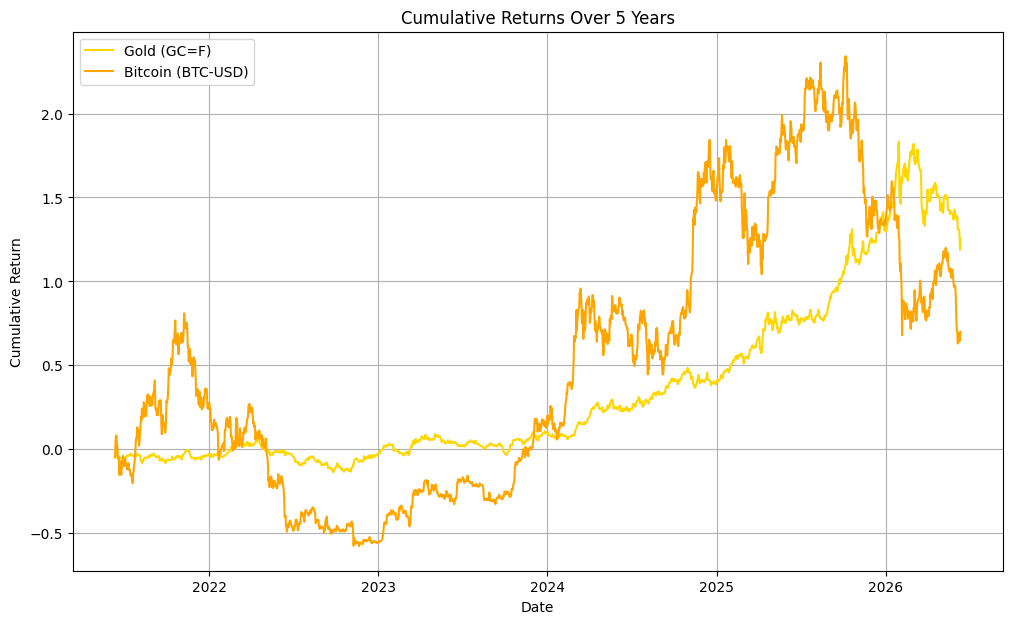

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the ticker symbols
ticker_symbols = ["GC=F", "BTC-USD"]

# Dictionary to store historical data for each ticker
historical_data = {}

for symbol in ticker_symbols:
    ticker = yf.Ticker(symbol)
    df_historical = ticker.history(period="5y")
    historical_data[symbol] = df_historical

# Calculate daily returns for each ticker
daily_returns = {}
for symbol, df in historical_data.items():
    daily_returns[symbol] = df['Close'].pct_change().dropna()

# Calculate cumulative returns for each ticker
cumulative_returns = {}
for symbol in daily_returns:
    cum_ret = (1 + daily_returns[symbol]).cumprod() - 1
    cumulative_returns[symbol] = cum_ret

plt.figure(figsize=(12, 7))

plt.plot(cumulative_returns['GC=F'].index, cumulative_returns['GC=F'], label='Gold (GC=F)', color='gold')
plt.plot(cumulative_returns['BTC-USD'].index, cumulative_returns['BTC-USD'], label='Bitcoin (BTC-USD)', color='orange')

plt.title('Cumulative Returns Over 5 Years')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

### Research Question 2: Which asset offers lower investment risk?

Based on the comprehensive risk analysis encompassing volatility, Sharpe Ratio, and Maximum Drawdown:

*   **Volatility (Standard Deviation of Daily Returns):**
    *   Gold (GC=F): ~0.0115
    *   Bitcoin (BTC-USD): ~0.0282
    *   **Conclusion:** Bitcoin exhibits significantly higher volatility, indicating greater price fluctuations.

*   **Sharpe Ratio (Risk-Adjusted Returns):**
    *   Gold (GC=F): 1.00
    *   Bitcoin (BTC-USD): 0.37
    *   **Conclusion:** Gold offers a substantially better risk-adjusted return, meaning it generates more return per unit of risk taken.

*   **Maximum Drawdown (Largest Peak-to-Trough Decline):**
    *   Gold (GC=F): -20.43%
    *   Bitcoin (BTC-USD): -76.63%
    *   **Conclusion:** Bitcoin experienced a much deeper and more severe drawdown from its peak, indicating higher downside risk.

Considering these metrics, **Gold (GC=F) consistently demonstrates a lower investment risk** profile compared to Bitcoin (BTC-USD) over the analyzed 5-year period. Gold has lower volatility, better risk-adjusted returns (higher Sharpe Ratio), and significantly less severe maximum drawdowns.

#### Volatility Analysis: Visualizing Daily Return Distributions

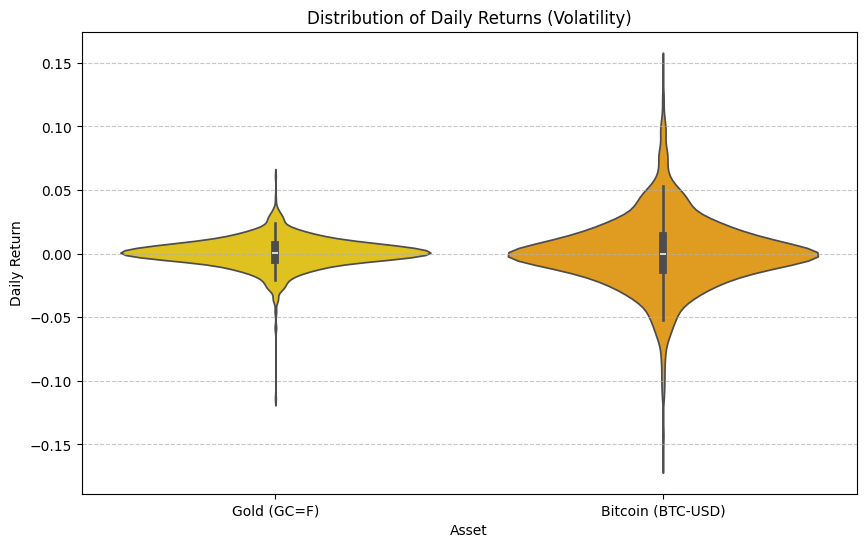

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the ticker symbols
ticker_symbols = ["GC=F", "BTC-USD"]

# Dictionary to store historical data for each ticker
historical_data = {}

for symbol in ticker_symbols:
    ticker = yf.Ticker(symbol)
    df_historical = ticker.history(period="5y")
    historical_data[symbol] = df_historical

# Calculate daily returns for each ticker
daily_returns = {}
for symbol, df in historical_data.items():
    daily_returns[symbol] = df['Close'].pct_change().dropna()

# Combine daily returns into a single DataFrame for easier plotting
combined_daily_returns = pd.DataFrame({
    'Gold (GC=F)': daily_returns['GC=F'],
    'Bitcoin (BTC-USD)': daily_returns['BTC-USD']
})

plt.figure(figsize=(10, 6))
sns.violinplot(data=combined_daily_returns, palette=['gold', 'orange'])
plt.title('Distribution of Daily Returns (Volatility)')
plt.ylabel('Daily Return')
plt.xlabel('Asset')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Overall Summary of Gold vs. Bitcoin (5-Year Analysis)

We have analyzed the performance of Gold (GC=F) and Bitcoin (BTC-USD) over a 5-year period, focusing on investment returns and investment risk.

**Key Findings:**

*   **Investment Returns (CAGR):**
    *   **Gold (GC=F):** ~19.13%
    *   **Bitcoin (BTC-USD):** ~11.31%
    *   **Conclusion:** Gold offered higher investment returns during this specific 5-year period.

*   **Investment Risk:**
    *   **Volatility (Standard Deviation of Daily Returns):** Gold (~0.0115) was significantly less volatile than Bitcoin (~0.0282).
    *   **Sharpe Ratio (Risk-Adjusted Returns):** Gold (1.00) showed a much better risk-adjusted return than Bitcoin (0.37).
    *   **Maximum Drawdown (Largest Peak-to-Trough Decline):** Gold (-20.43%) experienced a far less severe drawdown compared to Bitcoin (-76.63%).
    *   **Conclusion:** **Gold (GC=F) consistently demonstrates a lower investment risk** profile compared to Bitcoin (BTC-USD) over the analyzed 5-year period.

In summary, while Gold showed better returns and significantly lower risk in this particular 5-year window, Bitcoin presented a much riskier profile with higher price swings and potential for larger losses. An investor's choice between these two assets would heavily depend on their risk tolerance and investment goals, with Gold being suitable for more risk-averse investors seeking stability and Bitcoin for those willing to accept higher risk for potentially higher, though more volatile, returns.

### Final Conclusion: Gold vs. Bitcoin Investment Performance

Our 5-year comparative analysis of Gold (GC=F) and Bitcoin (BTC-USD) has provided a comprehensive overview of their investment performance and risk profiles.

**Key Takeaways:**

*   **Investment Returns:** Gold outperformed Bitcoin in terms of raw returns, with a CAGR of approximately 19.13% for Gold versus 11.31% for Bitcoin.

*   **Investment Risk:** Gold consistently demonstrated a significantly lower investment risk profile across all metrics:
    *   **Volatility:** Gold exhibited much lower daily return volatility (0.0115) compared to Bitcoin (0.0282).
    *   **Sharpe Ratio:** Gold yielded a substantially better risk-adjusted return (1.00) than Bitcoin (0.37).
    *   **Maximum Drawdown:** Gold experienced a considerably shallower maximum drawdown (-20.43%) compared to Bitcoin (-76.63%), indicating greater resilience to significant price declines.

**In summary, over the past five years, Gold presented itself as a more stable and less risky investment with superior returns in this specific period. Bitcoin, while offering substantial upside potential, came with a much higher degree of volatility and downside risk, as evidenced by its significantly larger drawdowns and lower risk-adjusted returns.**

An investor's choice between these two assets should align with their individual risk tolerance and investment objectives. Gold may be preferred by those seeking capital preservation and steady growth, while Bitcoin might appeal to investors with a higher risk appetite seeking potentially explosive, albeit volatile, gains.